<a href="https://colab.research.google.com/github/ankitpyj/Machine_Learning/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
netflix = pd.read_csv('/content/netflix_titles_2021.csv')

In [ ]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
netflix.shape

(8807, 12)

In [ ]:
netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
netflix.fillna(0,inplace=True) #It create the new dataframe but if we use the inplace then it update in old

In [ ]:
netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
netflix.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
netflix['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Text(0.5, 1.0, 'Movies and TV')

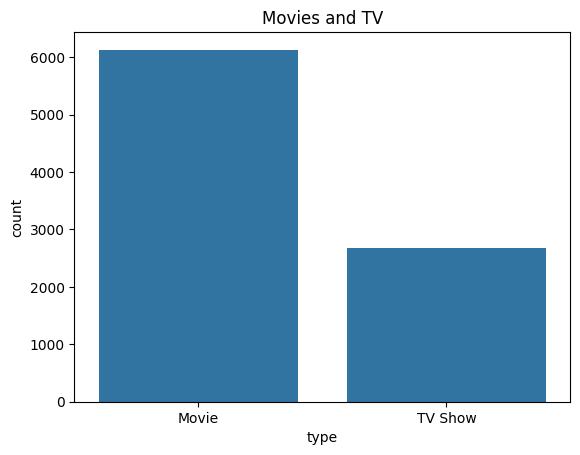

In [ ]:
sns.countplot(data=netflix, x='type')
plt.title("Movies and TV")

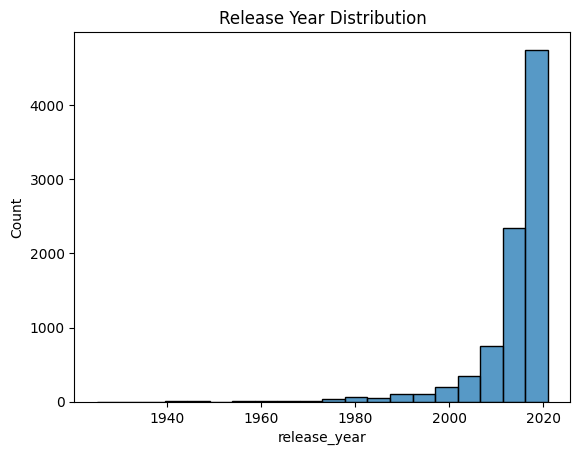

In [ ]:
#This shows how Netflix content has grown over years.

sns.histplot(netflix['release_year'],bins=20)
plt.title("Release Year Distribution")
plt.show()

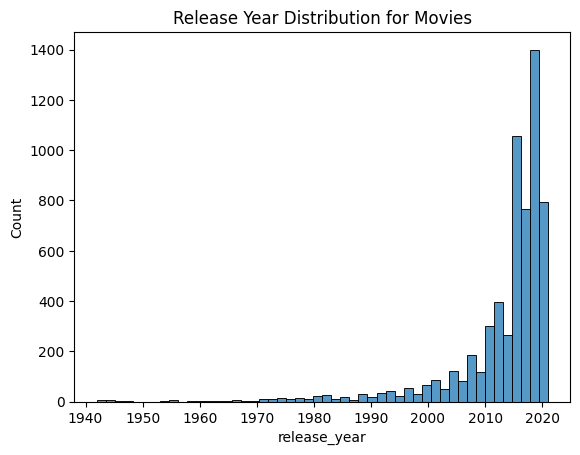

In [ ]:
sns.histplot(netflix[netflix['type'] == 'Movie']['release_year'], bins=50)
plt.title("Release Year Distribution for Movies")
plt.show()

Text(0.5, 1.0, 'Top 10 Countries')

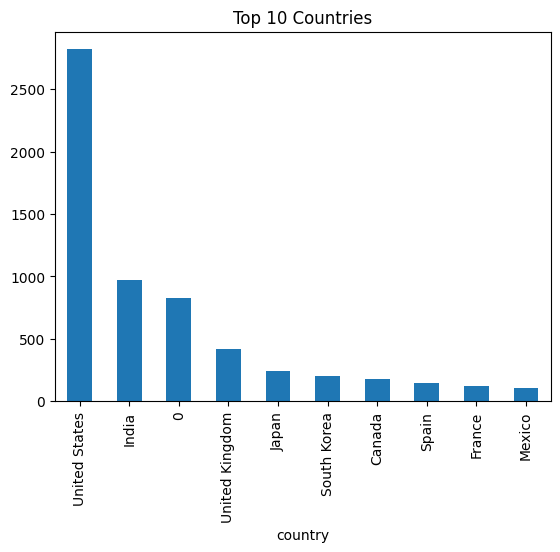

In [ ]:
#This shows which countries produce the most Netflix content. == United state

netflix['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")

In [ ]:
# From the EDA,
# we observed that Netflix contains more Movies than TV Shows.
# Most content was released after 2010.
# The USA produces the highest number of titles.
# Some missing values exist in director and cast columns.

ADVANCED

# **Feature 1: Extract year added**

In [ ]:
netflix.info()

#  6   date_added    8797 non-null   object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'],errors='coerce')

# 6   date_added    8709 non-null   datetime64[ns]

In [ ]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [ ]:
# EXtract year and month to ANALYZE

netflix['year_added']= netflix['date_added'].dt.year
netflix['month_added'] = netflix['date_added'].dt.month

# THis make to cols of year_added and month_added

In [ ]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,0,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,0,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",0,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,0,0,0,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,0,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


# **Feature 2: Separate Movie duration and TV seasons**

In [ ]:
netflix['duration_num'] = netflix['duration'].str.extract('(\d+)')
netflix['duration_num'] = pd.to_numeric(netflix['duration_num'], errors='coerce')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-174/4262885299.py:1: SyntaxWarning: invalid escape sequence '\d'
  netflix['duration_num'] = netflix['duration'].str.extract('(\d+)')


In [ ]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,0,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0
1,s2,TV Show,Blood & Water,0,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",0,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0
3,s4,TV Show,Jailbirds New Orleans,0,0,0,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0
4,s5,TV Show,Kota Factory,0,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0


# Feature 3: Create content age **feature**

In [ ]:
# This shows how old  after release content was added to Netflix

netflix['content_age'] = netflix['year_added'] - netflix['release_year']

In [ ]:
#Correlation Analysis
corr = netflix[['release_year','year_added','duration_num','content_age']].corr()

corr

,release_year,year_added,duration_num,content_age
release_year,1.000000,0.110473,-0.249182,-0.984167
year_added,0.110473,1.000000,0.016436,0.067434
duration_num,-0.249182,0.016436,1.000000,0.259009
content_age,-0.984167,0.067434,0.259009,1.000000


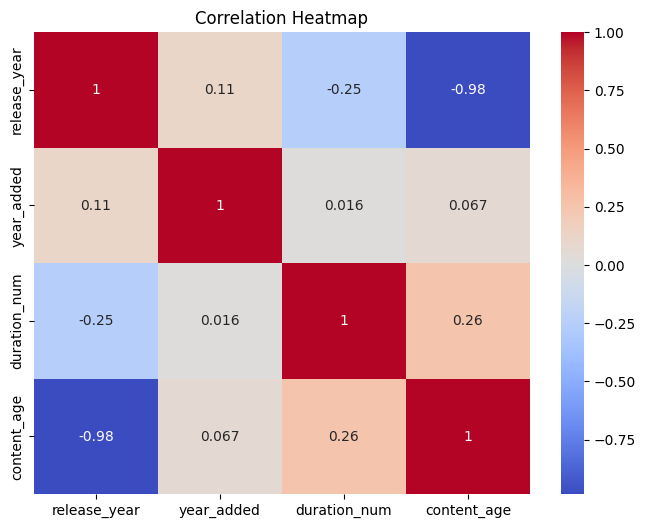

In [ ]:
# Heatmap visualization

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

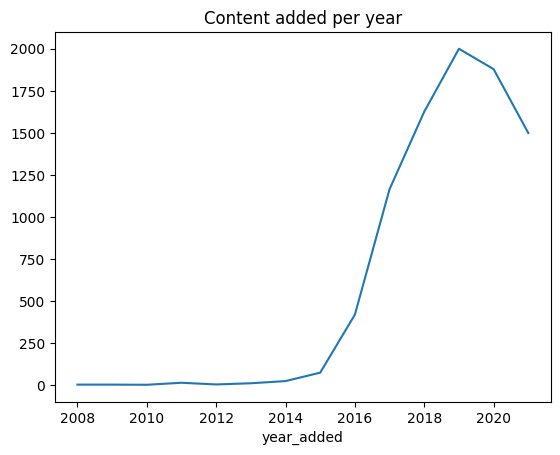

In [ ]:
netflix['year_added'].value_counts().sort_index().plot(kind='line')

plt.title("Content added per year")
plt.show()

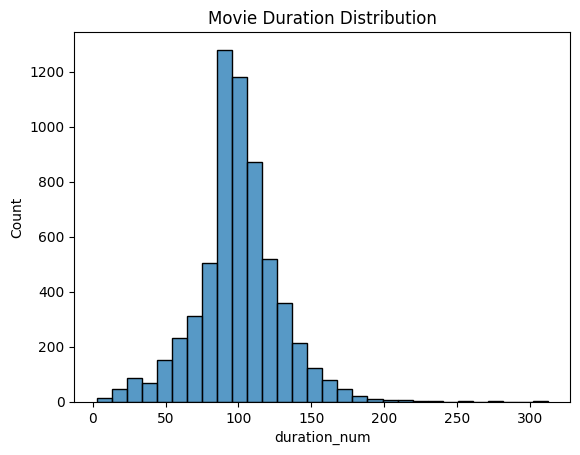

In [ ]:
#Movie duration distribution

sns.histplot(netflix[netflix['type']=='Movie']['duration_num'], bins=30)

plt.title("Movie Duration Distribution")
plt.show()

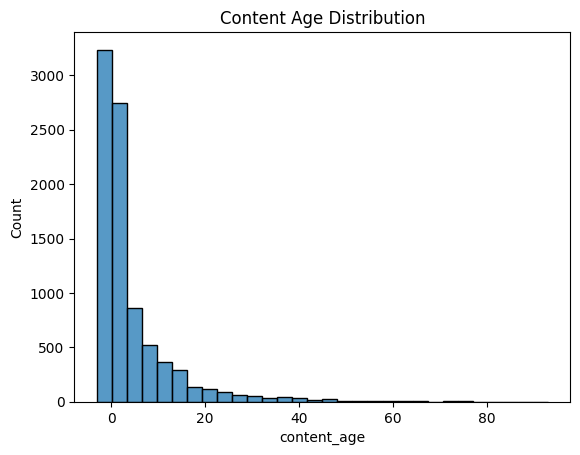

In [ ]:
#Content age distribution

sns.histplot(netflix['content_age'], bins=30)

plt.title("Content Age Distribution")
plt.show()

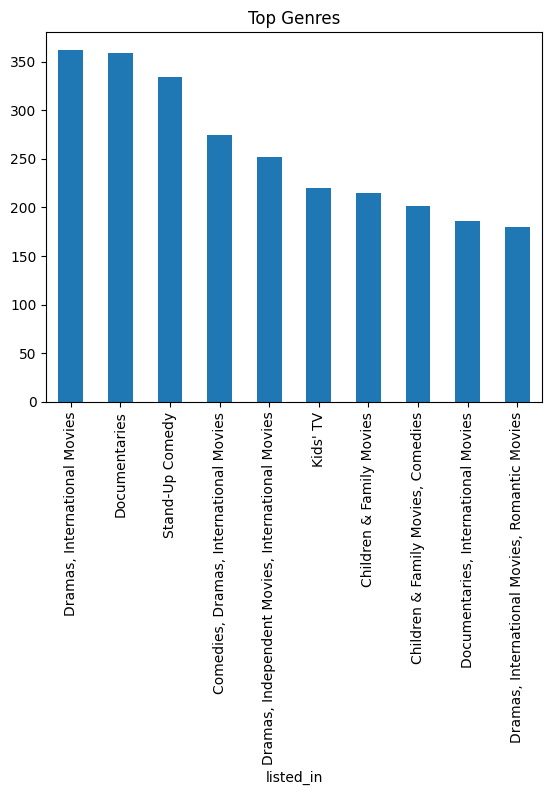

In [ ]:
netflix['listed_in'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")
plt.show()

<Axes: xlabel='rating', ylabel='count'>

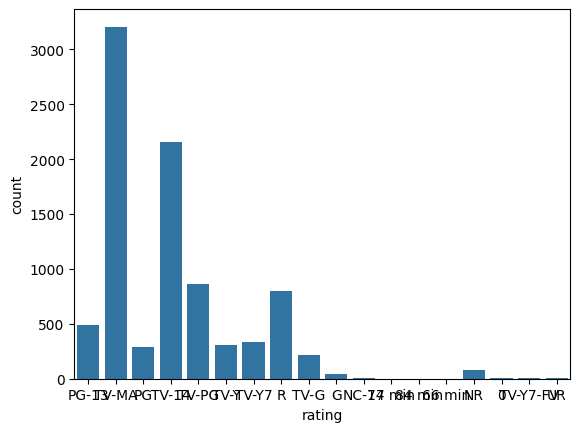

In [ ]:
sns.countplot(x='rating', data=netflix)


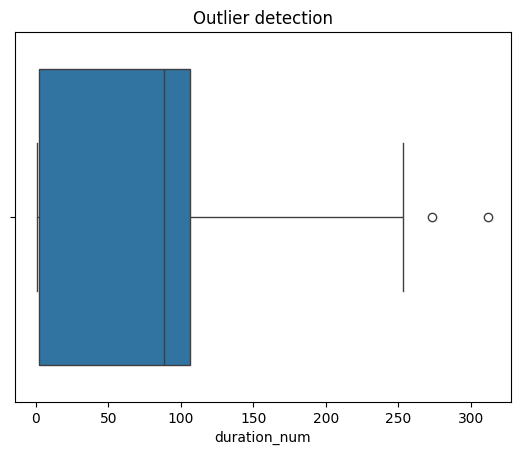

In [ ]:
sns.boxplot(x=netflix['duration_num'])

plt.title("Outlier detection")

plt.show()

In [ ]:
x = netflix['duration_num'].max()

netflix[netflix['duration_num'] == x]['title']

,title
4253,Black Mirror: Bandersnatch
